In [1]:
import os
import shutil
import random

SOURCE_DIR = r"C:\Users\ephra\OneDrive\Desktop\Application of AI project\Pest_Dataset"
OUTPUT_DIR = "pest_dataset(main)"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    # Filter only image files
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(IMAGE_EXTENSIONS)]

    random.shuffle(images)

    total = len(images)
    train_count = int(total * TRAIN_RATIO)
    val_count = int(total * VAL_RATIO)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    for split, split_images in zip(
        ["train", "validation", "test"],
        [train_images, val_images, test_images]
    ):
        split_class_dir = os.path.join(OUTPUT_DIR, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy2(src, dst)

print("✅ Dataset split completed successfully!")


✅ Dataset split completed successfully!


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "pest_dataset(main)/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "pest_dataset(main)/validation",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)


Found 4343 images belonging to 9 classes.
Found 1309 images belonging to 9 classes.


In [ ]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [6]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

C:\Users\ephra\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.5038 - loss: 1.8100 - val_accuracy: 0.5172 - val_loss: 1.5835
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5132 - loss: 1.6251 - val_accuracy: 0.5172 - val_loss: 1.5316
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.5192 - loss: 1.5588 - val_accuracy: 0.5325 - val_loss: 1.4587
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.5328 - loss: 1.5292 - val_accuracy: 0.5699 - val_loss: 1.4007
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5393 - loss: 1.4853 - val_accuracy: 0.5561 - val_loss: 1.3972
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.5512 - loss: 1.4601 - val_accuracy: 0.5760 - val_loss: 1.3365
Epoch 7/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.5561 - loss: 1.4098 - val_accuracy: 0.5882 - val_loss: 1.2788
Epoch 8/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.5579 - loss: 1.3832 - val_accu

In [7]:
model.save("pest_cnn_model.h5")
print("Custom CNN model saved successfully.")

Custom CNN model saved successfully.


In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "pest_dataset(main)/test",
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy:", accuracy)


Found 1352 images belonging to 9 classes.
43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 386ms/step - accuracy: 0.6368 - loss: 1.0986
Test Accuracy: 0.6368343234062195


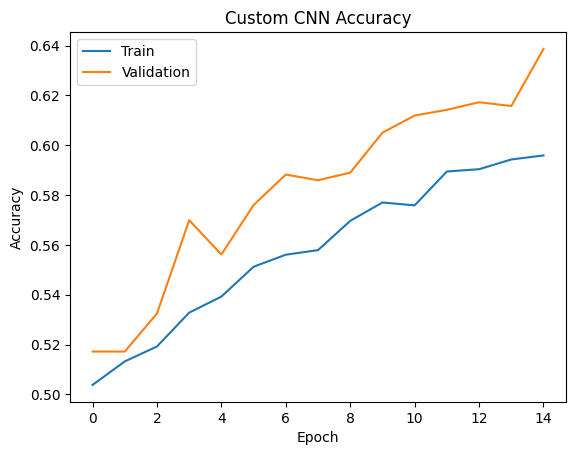

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [12]:
!pip install opencv-python ipywidgets --quiet

import cv2
import numpy as np
import tensorflow as tf
from IPython.display import display, Image as IPImage, clear_output
import ipywidgets as widgets
import threading
import time
from PIL import Image
import io
import base64

In [14]:
print(sorted(os.listdir("pest_dataset(main)/train")))

['Adristyrannus', 'Aleurocanthus spiniferus', 'Ampelophaga', 'Aphis citricola Vander Goot', 'Apolygus lucorum', 'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'aphids']


In [15]:
CLASS_NAMES = sorted(os.listdir("pest_dataset(main)/train"))
# This will give exactly:
# ['Adristyrannus', 'Aleurocanthus spiniferus', 'Ampelophaga', 
#  'Aphis citricola Vander Goot', 'Apolygus lucorum', 
#  'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'aphids']

PESTICIDE_GUIDE = {
    'Adristyrannus': {
        'pesticide': 'Chlorpyrifos 20% EC',
        'dose': '2.0 ml per litre of water'
    },
    'Aleurocanthus spiniferus': {   # Orange spiny whitefly
        'pesticide': 'Imidacloprid 17.8% SL',
        'dose': '0.5 ml per litre of water'
    },
    'Ampelophaga': {                 # Grape hawk moth
        'pesticide': 'Cypermethrin 10% EC',
        'dose': '1.0 ml per litre of water'
    },
    'Aphis citricola Vander Goot': { # Spirea aphid
        'pesticide': 'Thiamethoxam 25% WG',
        'dose': '0.5 g per litre of water'
    },
    'Apolygus lucorum': {            # Green plant bug
        'pesticide': 'Acetamiprid 20% SP',
        'dose': '0.4 g per litre of water'
    },
    'alfalfa plant bug': {
        'pesticide': 'Dimethoate 30% EC',
        'dose': '1.5 ml per litre of water'
    },
    'alfalfa seed chalcid': {
        'pesticide': 'Malathion 50% EC',
        'dose': '2.0 ml per litre of water'
    },
    'alfalfa weevil': {
        'pesticide': 'Carbaryl 50% WP',
        'dose': '2.0 g per litre of water'
    },
    'aphids': {
        'pesticide': 'Imidacloprid 17.8% SL',
        'dose': '0.5 ml per litre of water'
    },
}

In [16]:
import os
classes = sorted(os.listdir("pest_dataset(main)/train"))
for i, c in enumerate(classes):
    print(i, repr(c))

0 'Adristyrannus'
1 'Aleurocanthus spiniferus'
2 'Ampelophaga'
3 'Aphis citricola Vander Goot'
4 'Apolygus lucorum'
5 'alfalfa plant bug'
6 'alfalfa seed chalcid'
7 'alfalfa weevil'
8 'aphids'


In [18]:
# Quick sanity check
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("pest_dataset(main)/test/aphids/17126.jpg", target_size=(224, 224))
x   = image.img_to_array(img) / 255.0
x   = np.expand_dims(x, axis=0)
pred = model.predict(x)
print("Predicted:", CLASS_NAMES[np.argmax(pred)], f"({np.max(pred)*100:.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Predicted: aphids (89.1%)


In [1]:
from tensorflow.keras.models import load_model
model = load_model("pest_cnn_model.h5")

In [2]:
import os

CLASS_NAMES = sorted(os.listdir("pest_dataset(main)/train"))
print(CLASS_NAMES)

['Adristyrannus', 'Aleurocanthus spiniferus', 'Ampelophaga', 'Aphis citricola Vander Goot', 'Apolygus lucorum', 'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'aphids']


In [3]:
PESTICIDE_DB = {
    "Adristyrannus": {"pesticide": "Chlorpyrifos", "dose": "2 ml/L"},
    "Aleurocanthus spiniferus": {"pesticide": "Neem Oil", "dose": "3 ml/L"},
    "Ampelophaga": {"pesticide": "Spinosad", "dose": "0.3 ml/L"},
    "Aphis citricola Vander Goot": {"pesticide": "Imidacloprid", "dose": "0.5 ml/L"},
    "Apolygus lucorum": {"pesticide": "Thiamethoxam", "dose": "0.25 g/L"},
    "alfalfa plant bug": {"pesticide": "Malathion", "dose": "2 ml/L"},
    "alfalfa seed chalcid": {"pesticide": "Lambda-cyhalothrin", "dose": "0.5 ml/L"},
    "alfalfa weevil": {"pesticide": "Carbaryl", "dose": "1 g/L"},
    "aphids": {"pesticide": "Imidacloprid", "dose": "0.5 ml/L"}
}

In [4]:
import cv2

cap = cv2.VideoCapture(0)

print("Is camera opened?", cap.isOpened())

ret, frame = cap.read()
print("Frame received?", ret)

cap.release()

Is camera opened? True
Frame received? True


In [5]:
import cv2

for i in range(3):
    cap = cv2.VideoCapture(i)
    print(f"Camera {i}:", cap.isOpened())
    cap.release()

Camera 0: True
Camera 1: False
Camera 2: False


In [ ]:
import cv2
import numpy as np
import os
import time
from tensorflow.keras.models import load_model

# -------- LOAD MODEL --------
model = load_model("pest_cnn_model.h5", compile=False)

# -------- CLASS NAMES --------
CLASS_NAMES = sorted(os.listdir("pest_dataset(main)/train"))
# -------- CAMERA SETUP --------
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
cap.set(3, 640)
cap.set(4, 480)
time.sleep(2)

# -------- CONTROL VARIABLES --------
prev_label = None
stable_count = 0
STABLE_THRESHOLD = 5
CONF_THRESHOLD = 85  # stricter

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera not working")
        break

    frame = cv2.flip(frame, 1)

    # -------- LEAF DETECTION (GREEN FILTER) --------
    img = cv2.resize(frame, (224, 224))
    green_ratio = np.mean(img[:, :, 1])

    if green_ratio < 80:
        label = "Uncertain"
        confidence = 0
        stable_count = 0

    else:
        # -------- PREPROCESS --------
        img_array = img / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # -------- PREDICTION --------
        pred = model.predict(img_array, verbose=0)
        confidence = np.max(pred) * 100
        current_label = CLASS_NAMES[np.argmax(pred)]

        # -------- FILTER LOGIC --------
        if confidence < CONF_THRESHOLD or current_label not in PESTICIDE_DB:
            label = "Uncertain"
            stable_count = 0

        else:
            if current_label == prev_label:
                stable_count += 1
            else:
                stable_count = 1
                prev_label = current_label

            if stable_count >= STABLE_THRESHOLD:
                label = current_label
            else:
                label = "Uncertain"

    # -------- DISPLAY --------
    if label == "Uncertain":
        display_text = "Uncertain - Show infected leaf clearly"
        color = (0, 0, 255)
    else:
        info = PESTICIDE_DB.get(label)
        display_text = f"{label} | {info['pesticide']} | {info['dose']}"
        color = (0, 255, 0)

    cv2.putText(frame, display_text, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.putText(frame, f"Confidence: {confidence:.1f}%", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    cv2.imshow("Pest Detection System", frame)

    # -------- CONTROLS --------
    key = cv2.waitKey(1)

    if key == ord('q'):
        print("Stopping camera...")
        break

    elif key == ord('s'):
        cv2.imwrite("captured_leaf.jpg", frame)
        print("Image saved!")

# -------- CLEANUP --------
cap.release()
cv2.destroyAllWindows()

In [1]:
import shutil
import os

# Zips your model + dataset together into one file
shutil.make_archive("pest_project_full", "zip", ".", "pest_dataset(main)")

print("✅ Done! File saved as pest_project_full.zip")
print(f"Size: {os.path.getsize('pest_project_full.zip') / (1024*1024):.1f} MB")

✅ Done! File saved as pest_project_full.zip
Size: 272.9 MB


In [2]:
import zipfile

with zipfile.ZipFile("pest_model.zip", "w") as z:
    z.write("pest_cnn_model.h5")

print("✅ Model zipped as pest_model.zip")
print(f"Size: {os.path.getsize('pest_model.zip') / (1024*1024):.1f} MB")

✅ Model zipped as pest_model.zip
Size: 42.6 MB
